# 0.Import Library

In [37]:
import numpy as np
import pandas as pd
import kagglehub, os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1.Loading Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("archie2023/https-tunneling-predictive-analysis-dataset", output_dir="./dataset")

print("Path to dataset files:", path)

Path to dataset files: ./dataset


In [3]:
dataset_dir = "dataset/HTPA"
normal_traffic_path = os.path.join(dataset_dir, "normal_traffic.pickle")
tunnel_traffic_path = os.path.join(dataset_dir, "tunnel_traffic.pickle")

normal_traffic_list = pd.read_pickle(normal_traffic_path)
tunnel_traffic_list = pd.read_pickle(tunnel_traffic_path)

normal_traffic = pd.DataFrame(normal_traffic_list)
tunnel_traffic = pd.DataFrame(tunnel_traffic_list)

In [4]:
print("Normal Traffic Data:")
display(normal_traffic.head())

print("\nTunnel Traffic Data:")
display(tunnel_traffic.head())

Normal Traffic Data:


,StartTime,EndTime,ServerIP,ServerPort,ClientIP,ClientPort,Domain,SizeSeq,TimeSeq,UpBytes,DownBytes,UpPackets,DownPackets,TcpRtt
0,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_7d8db460,55768,VDomain_4161c316,"[517, -1460, -1460, -509, 126, 519, -51, -288,...","[0.0, -0.004692, -0.004733, -0.00499, 0.007453...",1681,3768,4,5,0.003349
1,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_9930233c,2324,VDomain_453dff09,"[517, -1348, -1348, -733, -51, -1348, -42, 830]","[0.0, -0.006159, -0.00621, -0.008124, -0.13026...",1347,4870,2,6,0.158856
2,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_c83a63ca,36879,VDomain_0628b5de,"[517, -1452, -1452, -51, -996, -572, -1452, -1...","[0.0, -0.005818, -0.005865, -0.081171, -0.2649...",1279,149611,2,105,0.002660
3,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_79027f98,29046,VDomain_0b436b06,"[228, -1460, -1460, -526, -1460, -1460, -1460,...","[0.0, -0.002979, -0.003041, -0.003227, -1.2766...",234,28521,2,21,0.002758
4,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_76a7c23a,58650,VDomain_87fbc82f,"[517, -1360, -51]","[0.0, -0.007468, -0.111613]",517,1411,1,2,0.002331



Tunnel Traffic Data:


,StartTime,EndTime,ServerIP,ServerPort,ClientIP,ClientPort,Domain,SizeSeq,TimeSeq,UpBytes,DownBytes,UpPackets,DownPackets,TcpRtt
0,1.713644e+09,1.713645e+09,VServerIP_038911af,40003,VClientIP_78896543,56763,VDomain_8a39b974,"[599, -1460, -1280, 64, 46, 31, -127, 31, 128,...","[0.0, -0.156772, -0.156772, 0.158116, 0.158298...",1377236,14988107,7019,15754,0.155038
1,1.713720e+09,1.713720e+09,VServerIP_038911af,40003,VClientIP_78896543,54895,VDomain_6f5c6c19,"[599, -1460, -1280, 64, 46, 31, -127, 31, -35,...","[0.0, -0.20291, -0.20291, 0.20417, 0.204353, 0...",1195292,18114878,6328,17375,0.155200
2,1.713741e+09,1.713742e+09,VServerIP_038911af,40003,VClientIP_78896543,59669,VDomain_8a39b974,"[535, -1460, -1278, 64, 46, 31, -105, 31, -35,...","[0.0, -0.158909, -0.158909, 0.161817, 0.162096...",1275376,14723357,6525,15160,0.157139
3,1.713752e+09,1.713752e+09,VServerIP_038911af,40003,VClientIP_78896543,64736,VDomain_8a39b974,"[599, -1460, -1279, 64, 46, 31, -105, 31, 1460...","[0.0, -0.159536, -0.159536, 0.160992, 0.161258...",1331244,16159342,6880,16459,0.184940
4,1.713550e+09,1.713550e+09,VServerIP_4ac04813,4430,VClientIP_78896543,60531,VDomain_85a20f91,"[274, -1460, -1460, -337, 64, 246, -236, -1460...","[0.0, -0.045552, -0.045552, -0.045552, 0.04812...",638,11651,5,11,0.043379


# 2.Exploratory Data Analysis

In [5]:
print(f"Normal Traffic Shape: {normal_traffic.shape}")
print(f"Tunnel Traffic Shape: {tunnel_traffic.shape}")

Normal Traffic Shape: (1154701, 14)
Tunnel Traffic Shape: (171143, 14)


In [6]:
normal_traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1154701 entries, 0 to 1154700
Data columns (total 14 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   StartTime    1154701 non-null  float64
 1   EndTime      1154701 non-null  float64
 2   ServerIP     1154701 non-null  str    
 3   ServerPort   1154701 non-null  int64  
 4   ClientIP     1154701 non-null  str    
 5   ClientPort   1154701 non-null  int64  
 6   Domain       1154322 non-null  str    
 7   SizeSeq      1154701 non-null  object 
 8   TimeSeq      1154701 non-null  object 
 9   UpBytes      1154701 non-null  int64  
 10  DownBytes    1154701 non-null  int64  
 11  UpPackets    1154701 non-null  int64  
 12  DownPackets  1154701 non-null  int64  
 13  TcpRtt       1154701 non-null  float64
dtypes: float64(3), int64(6), object(2), str(3)
memory usage: 123.3+ MB


In [7]:
tunnel_traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 171143 entries, 0 to 171142
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   StartTime    171143 non-null  float64
 1   EndTime      171143 non-null  float64
 2   ServerIP     171143 non-null  str    
 3   ServerPort   171143 non-null  int64  
 4   ClientIP     171143 non-null  str    
 5   ClientPort   171143 non-null  int64  
 6   Domain       171136 non-null  str    
 7   SizeSeq      171143 non-null  object 
 8   TimeSeq      171143 non-null  object 
 9   UpBytes      171143 non-null  int64  
 10  DownBytes    171143 non-null  int64  
 11  UpPackets    171143 non-null  int64  
 12  DownPackets  171143 non-null  int64  
 13  TcpRtt       171143 non-null  float64
dtypes: float64(3), int64(6), object(2), str(3)
memory usage: 18.3+ MB


In [8]:
normal_traffic.describe()

,StartTime,EndTime,ServerPort,ClientPort,UpBytes,DownBytes,UpPackets,DownPackets,TcpRtt
count,1.154701e+06,1.154701e+06,1.154701e+06,1.154701e+06,1.154701e+06,1.154701e+06,1.154701e+06,1.154701e+06,1.154701e+06
mean,1.711083e+09,1.711084e+09,5.822726e+02,5.257630e+04,4.701273e+03,1.764480e+04,9.132235e+00,1.713922e+01,7.408319e-02
std,1.665334e+07,1.665334e+07,1.787061e+03,1.349866e+04,7.581281e+04,4.680658e+05,6.029664e+02,6.333568e+02,1.109228e-01
min,1.597312e+09,1.597312e+09,2.500000e+01,2.000000e+00,5.000000e+01,0.000000e+00,1.000000e+00,0.000000e+00,-9.991500e-01
25%,1.713244e+09,1.713244e+09,4.430000e+02,5.102800e+04,1.007000e+03,4.463000e+03,3.000000e+00,6.000000e+00,7.389000e-03
50%,1.713749e+09,1.713749e+09,4.430000e+02,5.549800e+04,1.875000e+03,5.933000e+03,5.000000e+00,8.000000e+00,2.958600e-02
75%,1.713858e+09,1.713858e+09,4.430000e+02,6.043000e+04,3.633000e+03,8.592000e+03,7.000000e+00,1.100000e+01,7.995700e-02
max,1.714406e+09,1.714406e+09,5.844300e+04,6.553500e+04,5.469924e+07,3.228773e+08,5.802490e+05,5.451900e+05,3.782131e+01


In [9]:
tunnel_traffic.describe()

,StartTime,EndTime,ServerPort,ClientPort,UpBytes,DownBytes,UpPackets,DownPackets,TcpRtt
count,1.711430e+05,1.711430e+05,171143.000000,171143.000000,1.711430e+05,1.711430e+05,171143.000000,171143.000000,171143.000000
mean,1.713649e+09,1.713649e+09,22468.891442,52530.093325,4.470978e+03,2.128859e+04,10.624262,19.605307,0.071791
std,9.908607e+05,9.908674e+05,19909.501269,14156.222255,1.878577e+04,3.856678e+05,92.961655,293.066638,0.064643
min,1.709487e+09,1.709487e+09,443.000000,1025.000000,5.600000e+01,0.000000e+00,1.000000,0.000000,0.000002
25%,1.713172e+09,1.713172e+09,4045.000000,51407.000000,1.580000e+03,5.110000e+03,6.000000,7.000000,0.025660
50%,1.713419e+09,1.713419e+09,14391.000000,56094.000000,2.656000e+03,8.630000e+03,9.000000,10.000000,0.049816
75%,1.713928e+09,1.713928e+09,40001.000000,60689.000000,4.537000e+03,1.128000e+04,11.000000,14.000000,0.089859
max,1.715934e+09,1.715934e+09,65527.000000,65534.000000,4.017225e+06,1.212025e+08,30681.000000,86601.000000,2.673746


In [10]:
normal_traffic_missing = normal_traffic.isna().sum()
tunnel_traffic_missing = tunnel_traffic.isna().sum()

normal_traffic_missing_perc = ((normal_traffic_missing / len(normal_traffic)) * 100).round(2)
tunnel_traffic_missing_perc = ((tunnel_traffic_missing / len(tunnel_traffic)) * 100).round(2)

missing_normal_df = pd.DataFrame({
    "Normal Traffic Missing": normal_traffic_missing,
    "Persentase": normal_traffic_missing_perc,
})

missing_normal_df

,Normal Traffic Missing,Persentase
StartTime,0,0.00
EndTime,0,0.00
ServerIP,0,0.00
ServerPort,0,0.00
ClientIP,0,0.00
ClientPort,0,0.00
Domain,379,0.03
SizeSeq,0,0.00
TimeSeq,0,0.00
UpBytes,0,0.00


In [11]:
missing_tunnel_df = pd.DataFrame({
    "Tunnel Traffic Missing": tunnel_traffic_missing,
    "Persentase": tunnel_traffic_missing_perc
})

missing_tunnel_df

,Tunnel Traffic Missing,Persentase
StartTime,0,0.0
EndTime,0,0.0
ServerIP,0,0.0
ServerPort,0,0.0
ClientIP,0,0.0
ClientPort,0,0.0
Domain,7,0.0
SizeSeq,0,0.0
TimeSeq,0,0.0
UpBytes,0,0.0


# 3.Data Preprocessing

In [12]:
normal_traffic["Label"] = 0
tunnel_traffic["Label"] = 1

df = pd.concat([normal_traffic, tunnel_traffic], ignore_index=True)

In [13]:
df.head()

,StartTime,EndTime,ServerIP,ServerPort,ClientIP,ClientPort,Domain,SizeSeq,TimeSeq,UpBytes,DownBytes,UpPackets,DownPackets,TcpRtt,Label
0,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_7d8db460,55768,VDomain_4161c316,"[517, -1460, -1460, -509, 126, 519, -51, -288,...","[0.0, -0.004692, -0.004733, -0.00499, 0.007453...",1681,3768,4,5,0.003349,0
1,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_9930233c,2324,VDomain_453dff09,"[517, -1348, -1348, -733, -51, -1348, -42, 830]","[0.0, -0.006159, -0.00621, -0.008124, -0.13026...",1347,4870,2,6,0.158856,0
2,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_c83a63ca,36879,VDomain_0628b5de,"[517, -1452, -1452, -51, -996, -572, -1452, -1...","[0.0, -0.005818, -0.005865, -0.081171, -0.2649...",1279,149611,2,105,0.002660,0
3,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_79027f98,29046,VDomain_0b436b06,"[228, -1460, -1460, -526, -1460, -1460, -1460,...","[0.0, -0.002979, -0.003041, -0.003227, -1.2766...",234,28521,2,21,0.002758,0
4,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_76a7c23a,58650,VDomain_87fbc82f,"[517, -1360, -51]","[0.0, -0.007468, -0.111613]",517,1411,1,2,0.002331,0


In [14]:
def extract_sequence_features(df: pd.DataFrame):
    # SizeSeq features
    df["SizeSeq_len"] = df["SizeSeq"].apply(len)
    df["SizeSeq_mean"] = df["SizeSeq"].apply(np.mean)
    df["SizeSeq_std"] = df["SizeSeq"].apply(np.std)
    df["SizeSeq_min"] = df["SizeSeq"].apply(np.min)
    df["SizeSeq_max"] = df["SizeSeq"].apply(np.max)

    # TimeSeq features
    df["TimeSeq_len"] = df["TimeSeq"].apply(len)
    df["TimeSeq_mean"] = df["TimeSeq"].apply(np.mean)
    df["TimeSeq_std"] = df["TimeSeq"].apply(np.std)
    df["TimeSeq_min"] = df["TimeSeq"].apply(np.min)
    df["TimeSeq_max"] = df["TimeSeq"].apply(np.max)

    return df

In [15]:
df = extract_sequence_features(df)
df

,StartTime,EndTime,ServerIP,ServerPort,ClientIP,ClientPort,Domain,SizeSeq,TimeSeq,UpBytes,...,SizeSeq_len,SizeSeq_mean,SizeSeq_std,SizeSeq_min,SizeSeq_max,TimeSeq_len,TimeSeq_mean,TimeSeq_std,TimeSeq_min,TimeSeq_max
0,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_7d8db460,55768,VDomain_4161c316,"[517, -1460, -1460, -509, 126, 519, -51, -288,...","[0.0, -0.004692, -0.004733, -0.00499, 0.007453...",1681,...,9,-231.888889,741.302224,-1460,519,9,1.124943,3.205439,-0.057485,10.191142
1,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_9930233c,2324,VDomain_453dff09,"[517, -1348, -1348, -733, -51, -1348, -42, 830]","[0.0, -0.006159, -0.00621, -0.008124, -0.13026...",1347,...,8,-440.375000,821.409906,-1348,830,8,-0.044147,0.119550,-0.196032,0.189640
2,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_c83a63ca,36879,VDomain_0628b5de,"[517, -1452, -1452, -51, -996, -572, -1452, -1...","[0.0, -0.005818, -0.005865, -0.081171, -0.2649...",1279,...,100,-1403.820000,256.953513,-1452,517,100,-1.163633,0.480513,-1.744788,0.000000
3,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_79027f98,29046,VDomain_0b436b06,"[228, -1460, -1460, -526, -1460, -1460, -1460,...","[0.0, -0.002979, -0.003041, -0.003227, -1.2766...",234,...,23,-1229.869565,515.195219,-1460,228,23,-1.028402,0.549363,-1.350287,0.068486
4,1.597312e+09,1.597312e+09,VServerIP_0df7db85,443,VClientIP_76a7c23a,58650,VDomain_87fbc82f,"[517, -1360, -51]","[0.0, -0.007468, -0.111613]",517,...,3,-298.000000,785.934264,-1360,517,3,-0.039694,0.050946,-0.111613,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1325839,1.713168e+09,1.713168e+09,VServerIP_4b736709,29205,VClientIP_ca815fb3,55941,VDomain_683ca3c4,"[517, -1460, -1460, -1460, -277, 64, 919, -120...","[0.0, -0.10106, -0.101187, -0.101199, -0.10120...",2732,...,23,-441.000000,749.162083,-1460,919,23,-0.089657,38.011780,-128.900943,128.903120
1325840,1.713168e+09,1.713168e+09,VServerIP_4b736709,29205,VClientIP_ca815fb3,55999,VDomain_683ca3c4,"[517, -1460, -1460, -1460, -277, 64, 330, -120...","[0.0, -0.091176, -0.091243, -0.091259, -0.0912...",4424,...,24,-227.208333,769.493176,-1460,1146,24,-0.029366,1.166560,-2.183719,2.105206
1325841,1.713168e+09,1.713168e+09,VServerIP_4b736709,29205,VClientIP_ca815fb3,55983,VDomain_683ca3c4,"[517, -1460, -1460, -1460, -277, 64, 635, -169...","[0.0, -0.149285, -0.149287, -0.149326, -0.1493...",2490,...,13,-211.615385,791.164530,-1460,1177,13,-0.035700,25.845072,-65.881887,65.884850
1325842,1.713167e+09,1.713167e+09,VServerIP_2570b469,5631,VClientIP_ca33d1c1,53654,VDomain_d956ce60,"[301, -1460, -1460, -610, 64, 102, 108, -149, ...","[0.0, -0.285137, -0.28514, -0.285149, 0.285748...",707,...,11,-283.727273,597.205171,-1460,301,11,0.000226,0.582488,-1.100018,1.100362


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1325844 entries, 0 to 1325843
Data columns (total 25 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   StartTime     1325844 non-null  float64
 1   EndTime       1325844 non-null  float64
 2   ServerIP      1325844 non-null  str    
 3   ServerPort    1325844 non-null  int64  
 4   ClientIP      1325844 non-null  str    
 5   ClientPort    1325844 non-null  int64  
 6   Domain        1325458 non-null  str    
 7   SizeSeq       1325844 non-null  object 
 8   TimeSeq       1325844 non-null  object 
 9   UpBytes       1325844 non-null  int64  
 10  DownBytes     1325844 non-null  int64  
 11  UpPackets     1325844 non-null  int64  
 12  DownPackets   1325844 non-null  int64  
 13  TcpRtt        1325844 non-null  float64
 14  Label         1325844 non-null  int64  
 15  SizeSeq_len   1325844 non-null  int64  
 16  SizeSeq_mean  1325844 non-null  float64
 17  SizeSeq_std   1325844 non-null  float6

In [17]:
df.isna().sum()

StartTime         0
EndTime           0
ServerIP          0
ServerPort        0
ClientIP          0
ClientPort        0
Domain          386
SizeSeq           0
TimeSeq           0
UpBytes           0
DownBytes         0
UpPackets         0
DownPackets       0
TcpRtt            0
Label             0
SizeSeq_len       0
SizeSeq_mean      0
SizeSeq_std       0
SizeSeq_min       0
SizeSeq_max       0
TimeSeq_len       0
TimeSeq_mean      0
TimeSeq_std       0
TimeSeq_min       0
TimeSeq_max       0
dtype: int64

In [18]:
df = df.dropna()

In [19]:
df.isna().sum()

StartTime       0
EndTime         0
ServerIP        0
ServerPort      0
ClientIP        0
ClientPort      0
Domain          0
SizeSeq         0
TimeSeq         0
UpBytes         0
DownBytes       0
UpPackets       0
DownPackets     0
TcpRtt          0
Label           0
SizeSeq_len     0
SizeSeq_mean    0
SizeSeq_std     0
SizeSeq_min     0
SizeSeq_max     0
TimeSeq_len     0
TimeSeq_mean    0
TimeSeq_std     0
TimeSeq_min     0
TimeSeq_max     0
dtype: int64

In [20]:
num_cols = df.select_dtypes(include="number").columns
num_cols

Index(['StartTime', 'EndTime', 'ServerPort', 'ClientPort', 'UpBytes',
       'DownBytes', 'UpPackets', 'DownPackets', 'TcpRtt', 'Label',
       'SizeSeq_len', 'SizeSeq_mean', 'SizeSeq_std', 'SizeSeq_min',
       'SizeSeq_max', 'TimeSeq_len', 'TimeSeq_mean', 'TimeSeq_std',
       'TimeSeq_min', 'TimeSeq_max'],
      dtype='str')

C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_18712\4201803323.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Label", data=df, palette="flare")


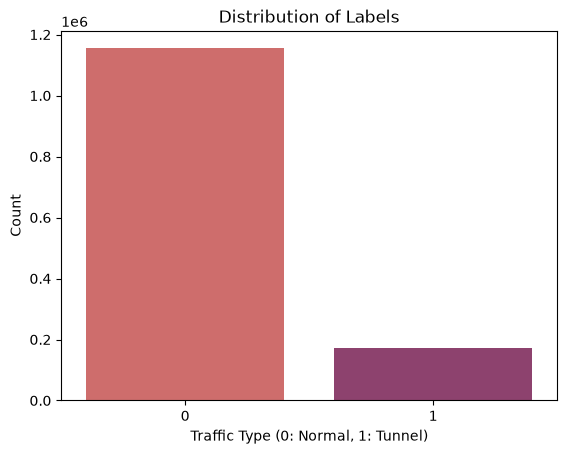

In [21]:
sns.countplot(x="Label", data=df, palette="flare")
plt.title("Distribution of Labels")
plt.xlabel("Traffic Type (0: Normal, 1: Tunnel)")
plt.ylabel("Count")
plt.show()

**Univariate Analysis**

C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_18712\3015580031.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  axes = sns.kdeplot(data=df, x=col, hue="Label", shade=True, ax=ax[i])
C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_18712\3015580031.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  axes = sns.kdeplot(data=df, x=col, hue="Label", shade=True, ax=ax[i])
C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_18712\3015580031.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  axes = sns.kdeplot(data=df, x=col, hue="Label", shade=True, ax=ax[i])
C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_18712\3015580031

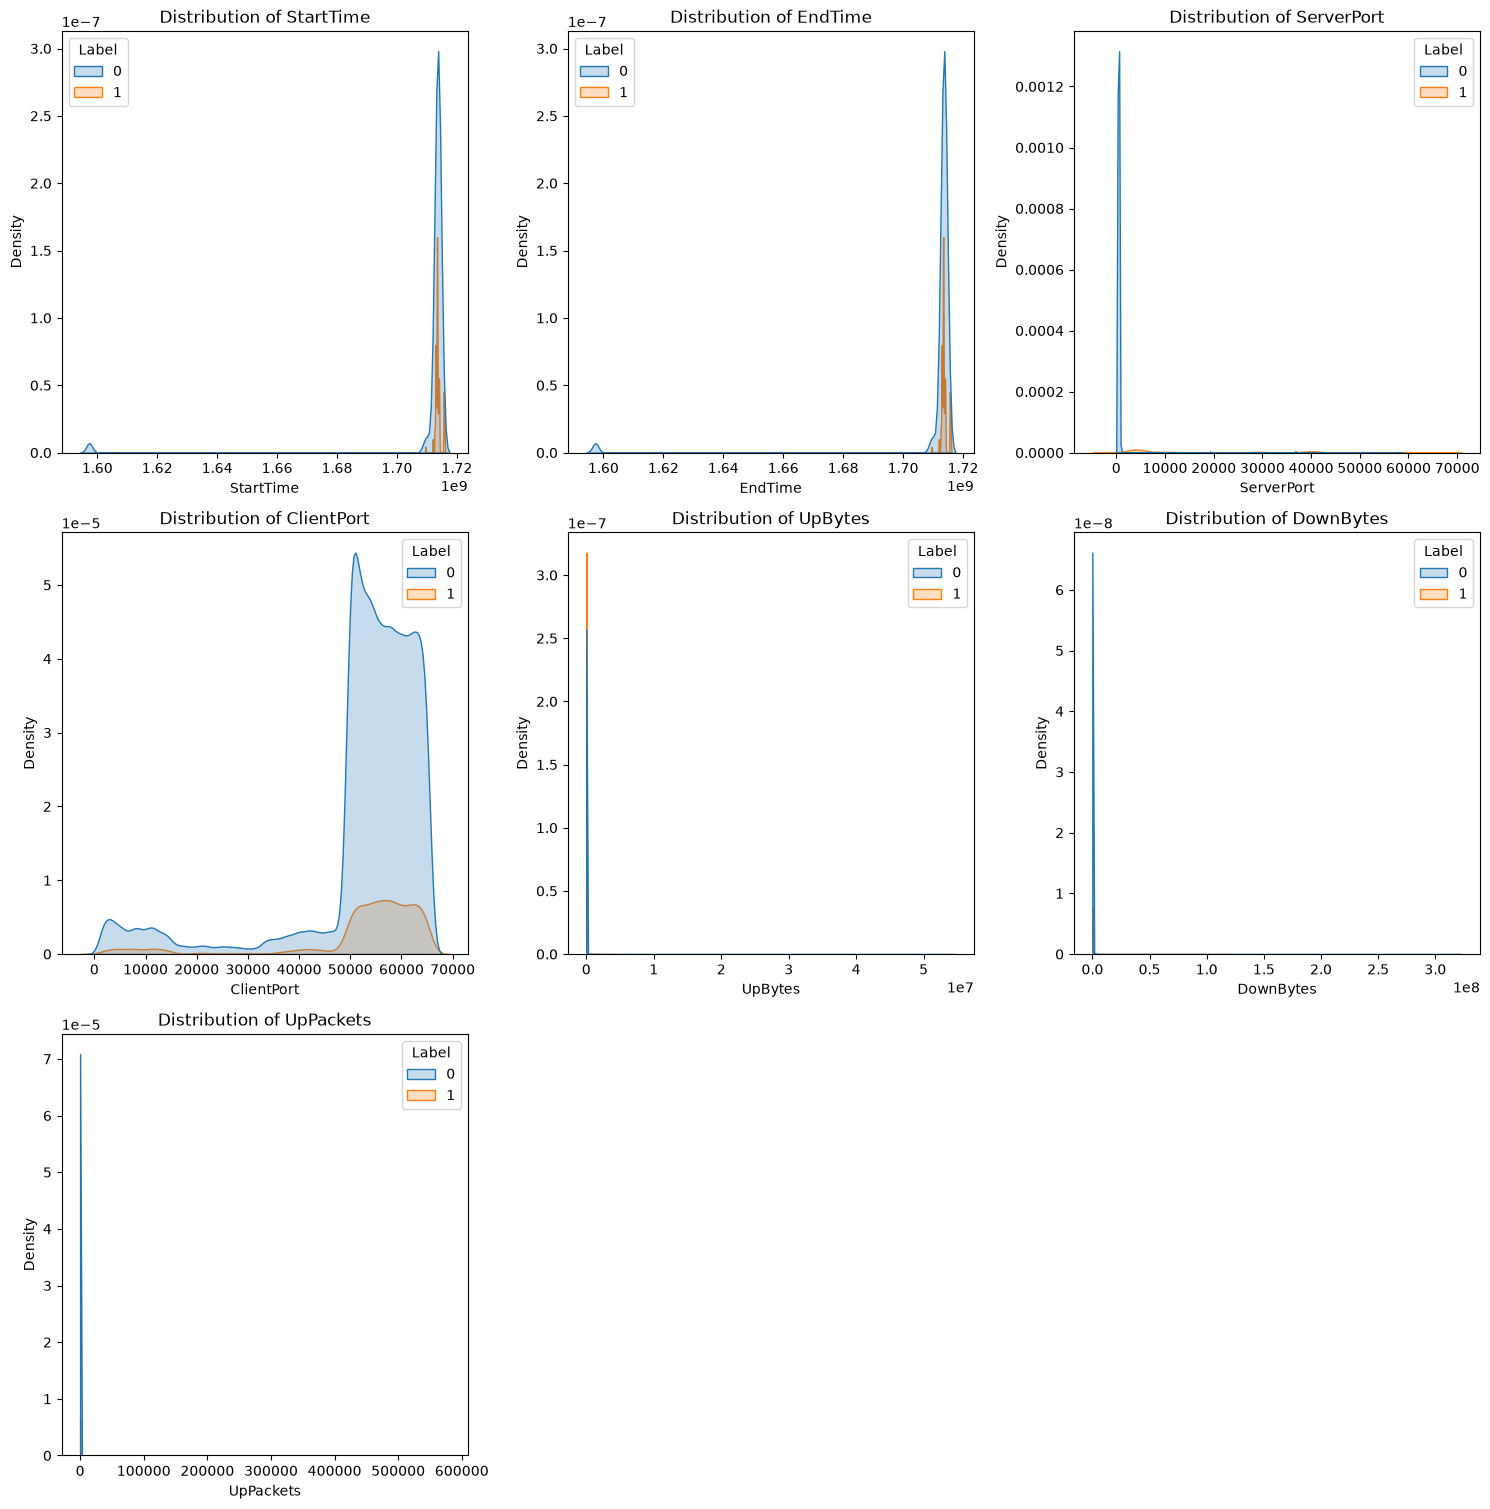

In [22]:
import math

n_rows = len(num_cols)
n_cols = math.ceil(n_rows / 3)

fig, ax = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    axes = sns.kdeplot(data=df, x=col, hue="Label", shade=True, ax=ax[i])
    axes.set(title=f"Distribution of {col}")

for i in range(n_cols, len(ax)):
    plt.delaxes(ax[i])

plt.tight_layout()
plt.show()

**Multivariate**

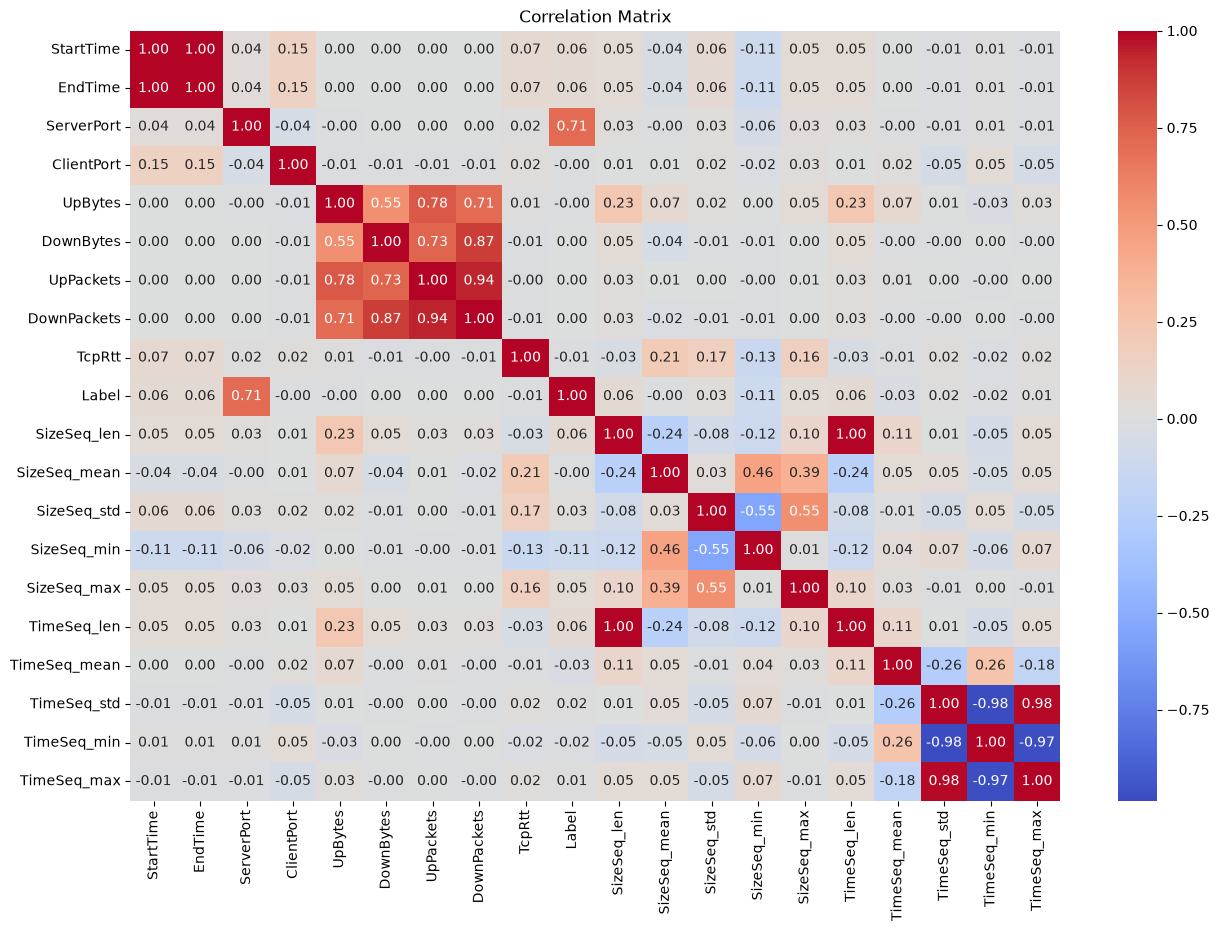

In [23]:
plt.figure(figsize=(15, 10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Feature Engineering**

In [24]:
df["Duration"] = df["EndTime"] - df["StartTime"]
df["Packet_Ratio"] = df["UpPackets"] - (df["DownPackets"] + 1)
df["Byte_Ratio"] = df["UpBytes"] / (df["DownBytes"] + 1)

In [25]:
df = df[num_cols].sample(frac=1)

X = df.drop(["Label"], axis=1)
y = df["Label"]

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
train_size = int(len(X_scaled) * 0.8)

X_train, X_test, y_train, y_test = X_scaled[:train_size], X_scaled[train_size:], y[:train_size], y[train_size:]

print("Total: {}".format(len(X_scaled)))
print("Total train dataset: {}".format(len(X_train)))
print("Total test dataset: {}".format(len(X_test)))

Total: 1325458
Total train dataset: 1060366
Total test dataset: 265092


# 4.Modeling

In [28]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [29]:
y_pred = lr.predict(X_train)

In [31]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97    923524
           1       0.93      0.69      0.79    136842

    accuracy                           0.95   1060366
   macro avg       0.94      0.84      0.88   1060366
weighted avg       0.95      0.95      0.95   1060366



In [32]:
y_pred_test = lr.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97    230798
           1       0.93      0.69      0.79     34294

    accuracy                           0.95    265092
   macro avg       0.94      0.84      0.88    265092
weighted avg       0.95      0.95      0.95    265092



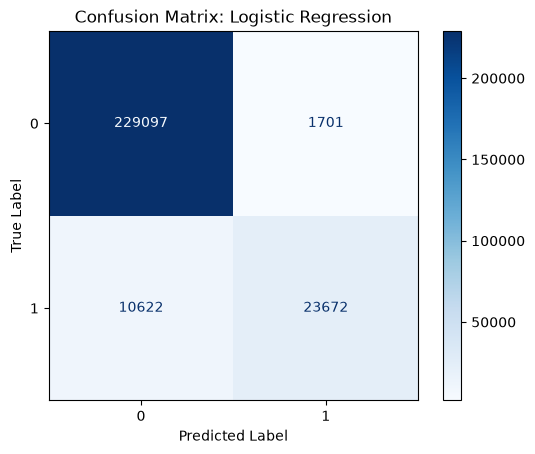

In [35]:
cm_lr = confusion_matrix(y_test, y_pred_test)

cm = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
cm.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [38]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    230798
           1       1.00      1.00      1.00     34294

    accuracy                           1.00    265092
   macro avg       1.00      1.00      1.00    265092
weighted avg       1.00      1.00      1.00    265092



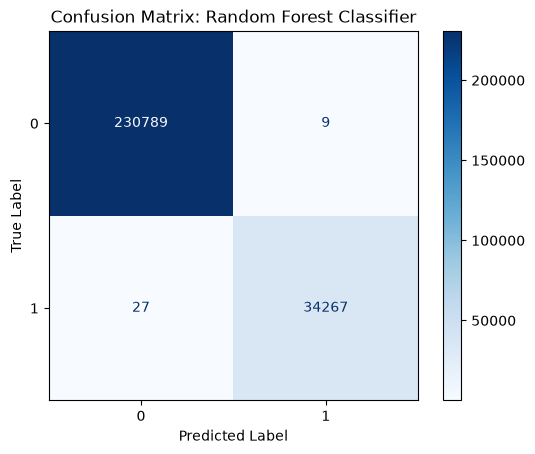

In [40]:
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

cm = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
cm.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Random Forest Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()